# Model Investigation

Inspecting how the EN→CY translation model works internally: attention patterns, token probabilities, and embedding space.

In [1]:
import sys
sys.path.insert(0, "..")

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from src import model as model_module, train, utils
from src.tokenizer import load_tokenizer

run_path = utils.get_run_path({"name": "base", "locations": {"runs_dir": "../runs"}})
config = utils.load_config(run_path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = load_tokenizer(run_path)
transformer = model_module.build_transformer(config).to(device)
checkpoint = train.load_checkpoint(run_path, 50000, device)
transformer.load_state_dict(checkpoint["model_state_dict"])
transformer.eval()
print("Model loaded.")

/home/mdpead/en-cy-translation/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded.


## Translate and capture internals

Uses forward hooks to capture attention weights and token probabilities from every decoder layer without modifying the model code.

In [ ]:
def capture_all_layers(text, max_length=256):
    """Translate and capture self-attention, cross-attention, and token probabilities from ALL decoder layers."""
    src_ids = tokenizer(text, return_tensors="pt")["input_ids"].to(device)
    src_mask = (src_ids != tokenizer.pad_token_id).to(device)
    src_tokens = tokenizer.convert_ids_to_tokens(src_ids[0])

    with torch.no_grad():
        src_enc = transformer.encode(src_ids, src_mask)

    tgt_ids = torch.tensor([[tokenizer.bos_token_id]], device=device)
    tgt_tokens = []
    all_probs = []
    all_step_self_attns = []
    all_step_cross_attns = []

    num_layers = len(transformer.decoder.layers)

    for step in range(max_length - 1):
        tgt_mask = torch.ones(tgt_ids.shape, dtype=torch.bool, device=device)

        captured_self = {}
        captured_cross = {}
        def make_hook(store, layer_idx):
            def hook_fn(module, args, output):
                q, k, v, attn_mask = args
                Q = module.W_q(q)
                K = module.W_k(k)
                Q_mh = Q.reshape(Q.shape[0], Q.shape[1], module.num_heads, module.d_h).permute(0, 2, 1, 3)
                K_mh = K.reshape(K.shape[0], K.shape[1], module.num_heads, module.d_h).permute(0, 2, 1, 3)
                attn_raw = torch.matmul(Q_mh, K_mh.transpose(-1, -2)) / (module.d_h ** 0.5)
                attn_mask_mh = attn_mask.unsqueeze(1).expand(-1, module.num_heads, -1, -1)
                fill_value = torch.finfo(attn_raw.dtype).min
                attn_masked = attn_raw.masked_fill(~attn_mask_mh, fill_value)
                attn_weights = torch.softmax(attn_masked, -1)
                store[layer_idx] = attn_weights[0, :, -1, :].detach().cpu().numpy()
            return hook_fn

        handles = []
        for i, layer in enumerate(transformer.decoder.layers):
            handles.append(layer.self_attention.register_forward_hook(make_hook(captured_self, i)))
            handles.append(layer.cross_attention.register_forward_hook(make_hook(captured_cross, i)))

        with torch.no_grad():
            tgt_dec = transformer.decode(src_enc, tgt_ids, src_mask, tgt_mask)
            logits = transformer.output(tgt_dec)

        for h in handles:
            h.remove()

        last_logits = logits[0, -1, :]
        probs = F.softmax(last_logits, dim=-1)
        top_probs, top_ids = probs.topk(10)
        all_probs.append({
            "top_tokens": tokenizer.convert_ids_to_tokens(top_ids),
            "top_probs": top_probs.cpu().numpy(),
            "entropy": -(probs * probs.log()).sum().item(),
        })

        all_step_self_attns.append(captured_self)
        all_step_cross_attns.append(captured_cross)

        next_token = last_logits.argmax().unsqueeze(0).unsqueeze(0)
        tgt_ids = torch.cat([tgt_ids, next_token], dim=-1)
        token = tokenizer.convert_ids_to_tokens(next_token[0])[0]
        tgt_tokens.append(token)

        if next_token.item() == tokenizer.eos_token_id:
            break

    return {
        "src_text": text,
        "src_tokens": src_tokens,
        "tgt_text": tokenizer.decode(tgt_ids[0], skip_special_tokens=True),
        "tgt_tokens": tgt_tokens,
        "probs": all_probs,
        "self_attns": all_step_self_attns,
        "cross_attns": all_step_cross_attns,
    }

In [ ]:
result = capture_all_layers("The Welsh Government is committed to improving public services.")
print(f"EN: {result['src_text']}")
print(f"CY: {result['tgt_text']}")
print(f"Source tokens: {result['src_tokens']}")
print(f"Target tokens: {result['tgt_tokens']}")

## Cross-attention heatmap

Shows which source tokens the decoder attends to when generating each target token. Averaged across all 8 heads.

In [ ]:
num_layers = len(transformer.decoder.layers)
num_heads = transformer.decoder.layers[0].cross_attention.num_heads

# Average cross-attention across all layers and heads
cross_attn_all = np.stack([
    np.stack([result["cross_attns"][step][layer] for layer in range(num_layers)]).mean(axis=(0, 1))
    for step in range(len(result["tgt_tokens"]))
])

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(cross_attn_all, aspect="auto", cmap="Blues")
ax.set_xticks(range(len(result["src_tokens"])))
ax.set_xticklabels(result["src_tokens"], rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(result["tgt_tokens"])))
ax.set_yticklabels(result["tgt_tokens"], fontsize=9)
ax.set_xlabel("Source tokens")
ax.set_ylabel("Target tokens")
ax.set_title("Cross-attention (averaged over all layers and heads)")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## Cross-attention by layer

How attention patterns differ across layers.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for layer, ax in enumerate(axes.flat):
    layer_attn = np.stack([
        result["cross_attns"][step][layer].mean(axis=0)
        for step in range(len(result["tgt_tokens"]))
    ])
    ax.imshow(layer_attn, aspect="auto", cmap="Blues")
    ax.set_title(f"Layer {layer}")
    ax.set_xticks(range(len(result["src_tokens"])))
    ax.set_xticklabels(result["src_tokens"], rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(result["tgt_tokens"])))
    ax.set_yticklabels(result["tgt_tokens"], fontsize=7)
plt.suptitle("Cross-attention by layer (averaged over heads)")
plt.tight_layout()
plt.show()

## Token prediction confidence

Shows the model's top predictions and entropy (uncertainty) at each decoding step.

In [6]:
# Top predictions at each step
for i, (token, prob_info) in enumerate(zip(result["tgt_tokens"], result["probs"])):
    top3 = ", ".join(f"{t}({p:.2f})" for t, p in zip(prob_info["top_tokens"][:3], prob_info["top_probs"][:3]))
    print(f"  Step {i:>2}: chose '{token}' | top3: {top3} | entropy: {prob_info['entropy']:.2f}")

  Step  0: chose 'Mae' | top3: Mae(0.94), Nod(0.00), Bydd(0.00) | entropy: 0.79
  Step  1: chose 'Llywodraeth' | top3: Llywodraeth(0.92), llywodraeth(0.00), Lywodraeth(0.00) | entropy: 0.96
  Step  2: chose 'Cymru' | top3: Cymru(0.85), Cymru'n(0.05), Cymru,(0.00) | entropy: 1.42
  Step  3: chose 'wedi' | top3: wedi(0.73), yn(0.19), am(0.00) | entropy: 1.49
  Step  4: chose 'ymrwymo' | top3: ymrwymo(0.92), ym(0.00), ymrwym(0.00) | entropy: 0.92
  Step  5: chose 'i' | top3: i(0.90), ##'n(0.00), i'r(0.00) | entropy: 1.30
  Step  6: chose 'wella' | top3: wella(0.84), wella'r(0.02), gwella(0.00) | entropy: 1.80
  Step  7: chose 'gwasanaethau' | top3: gwasanaethau(0.92), ei(0.01), gwasanaeth(0.00) | entropy: 0.94
  Step  8: chose 'cyhoeddus.' | top3: cyhoeddus.(0.94), cyhoeddus(0.01), gwlad(0.00) | entropy: 0.67
  Step  9: chose '[EOS]' | top3: [EOS](0.91), ##"(0.00), .(0.00) | entropy: 1.14


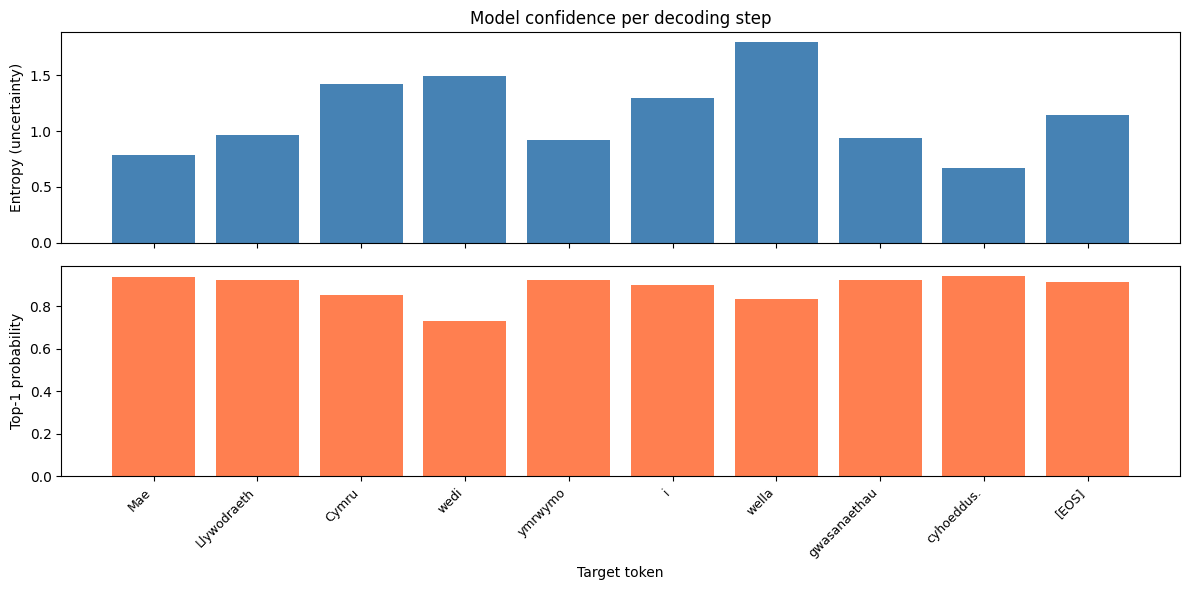

In [7]:
# Entropy over decoding steps
entropies = [p["entropy"] for p in result["probs"]]
top1_probs = [p["top_probs"][0] for p in result["probs"]]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.bar(range(len(entropies)), entropies, color="steelblue")
ax1.set_ylabel("Entropy (uncertainty)")
ax1.set_title("Model confidence per decoding step")

ax2.bar(range(len(top1_probs)), top1_probs, color="coral")
ax2.set_ylabel("Top-1 probability")
ax2.set_xticks(range(len(result["tgt_tokens"])))
ax2.set_xticklabels(result["tgt_tokens"], rotation=45, ha="right", fontsize=9)
ax2.set_xlabel("Target token")
plt.tight_layout()
plt.show()

## Embedding space

PCA and t-SNE of the learned token embeddings. Do English and Welsh words cluster? Do similar concepts end up near each other?

In [8]:
# Get source (encoder) embeddings
src_emb = transformer.src_embedding.E.detach().cpu().numpy()
vocab = tokenizer.get_vocab()
id_to_token = {v: k for k, v in vocab.items()}
tokens = [id_to_token.get(i, f"[{i}]") for i in range(len(src_emb))]

# Filter to real tokens (skip ## subwords and specials for clarity)
mask = [not t.startswith("##") and not t.startswith("[") and len(t) > 1 for t in tokens]
filtered_emb = src_emb[mask]
filtered_tokens = [t for t, m in zip(tokens, mask) if m]

print(f"Plotting {len(filtered_tokens)} tokens (excluding subwords and specials)")

Plotting 11355 tokens (excluding subwords and specials)


In [9]:
# Find nearest neighbours for specific tokens
def nearest_neighbours(token, embeddings, token_list, n=10):
    if token not in token_list:
        print(f"'{token}' not in vocabulary")
        return
    idx = token_list.index(token)
    vec = embeddings[idx]
    dists = np.linalg.norm(embeddings - vec, axis=1)
    nearest = np.argsort(dists)[1:n+1]
    print(f"Nearest to '{token}':")
    for i in nearest:
        print(f"  {token_list[i]:20s} dist={dists[i]:.3f}")

for word in ["government", "llywodraeth", "school", "ysgol", "water", "health"]:
    nearest_neighbours(word, filtered_emb, filtered_tokens)
    print()

Nearest to 'government':
  Government           dist=1.241
  drefniadau           dist=1.259
  nghyd-destun         dist=1.268
  hyrwyddo             dist=1.270
  graddedigion         dist=1.271
  allanol              dist=1.273
  disgwyliedig         dist=1.274
  dioddef              dist=1.275
  cyfeiriadau          dist=1.275
  ohono                dist=1.275

Nearest to 'llywodraeth':
  gofal.               dist=0.482
  hon,                 dist=0.483
  Caerdydd:            dist=0.484
  heintiau             dist=0.485
  Nyrs                 dist=0.486
  hwyl                 dist=0.488
  lluniau              dist=0.488
  o'ch                 dist=0.491
  Sicrhau              dist=0.491
  Addysgir             dist=0.491

Nearest to 'school':
  School               dist=1.124
  gwael                dist=1.224
  Cyfran               dist=1.227
  atoch                dist=1.229
  ohono                dist=1.232
  chyd                 dist=1.233
  amcan                dist=1.234
  Fyfyrw

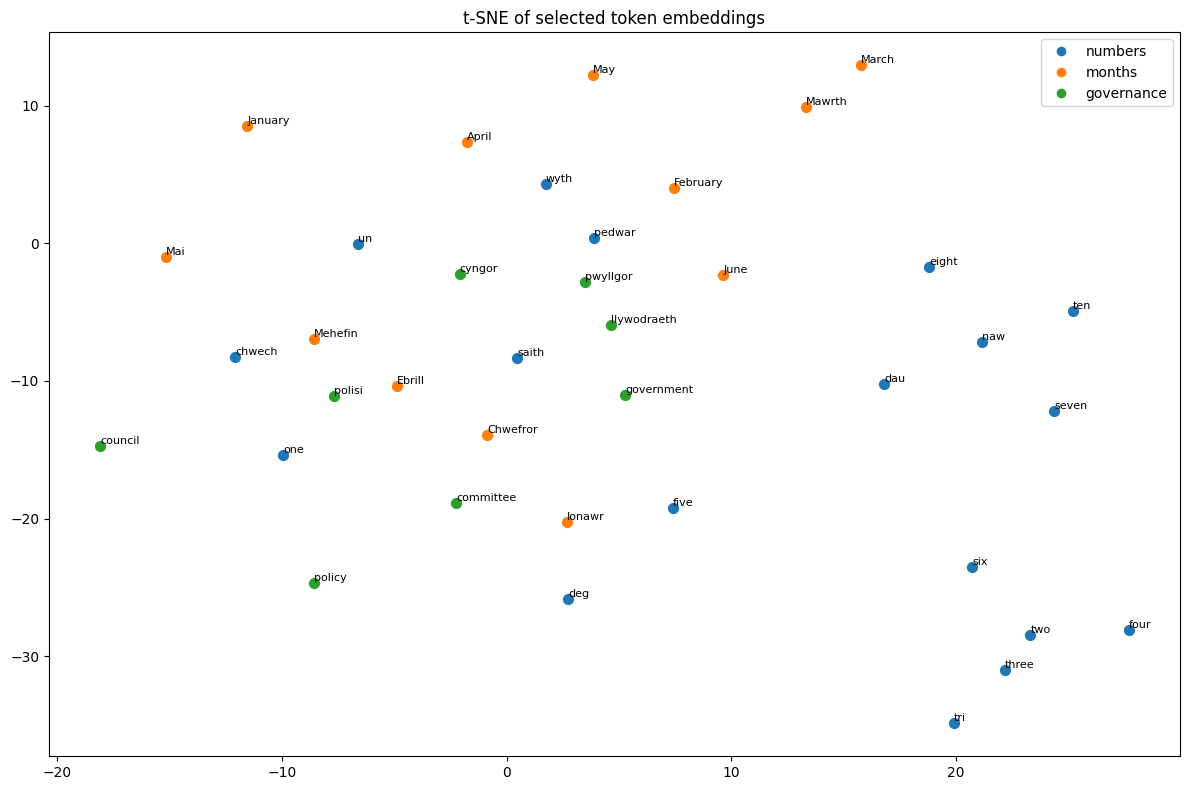

In [10]:
# t-SNE of selected token groups
groups = {
    "numbers": ["one", "two", "three", "four", "five", "six", "seven", "eight", "nine", "ten",
                 "un", "dau", "tri", "pedwar", "pump", "chwech", "saith", "wyth", "naw", "deg"],
    "months": ["January", "February", "March", "April", "May", "June",
               "Ionawr", "Chwefror", "Mawrth", "Ebrill", "Mai", "Mehefin"],
    "governance": ["government", "council", "parliament", "committee", "policy",
                   "llywodraeth", "cyngor", "senedd", "pwyllgor", "polisi"],
}

plot_tokens = []
plot_labels = []
plot_indices = []
for group, words in groups.items():
    for w in words:
        if w in filtered_tokens:
            plot_tokens.append(w)
            plot_labels.append(group)
            plot_indices.append(filtered_tokens.index(w))

plot_emb = filtered_emb[plot_indices]

tsne = TSNE(n_components=2, perplexity=min(5, len(plot_emb)-1), random_state=42)
coords = tsne.fit_transform(plot_emb)

fig, ax = plt.subplots(figsize=(12, 8))
colors = {"numbers": "tab:blue", "months": "tab:orange", "governance": "tab:green"}
for i, (token, label) in enumerate(zip(plot_tokens, plot_labels)):
    ax.scatter(coords[i, 0], coords[i, 1], c=colors[label], s=50)
    ax.annotate(token, (coords[i, 0], coords[i, 1]), fontsize=8, ha="left", va="bottom")

from matplotlib.lines import Line2D
legend = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=8, label=l)
          for l, c in colors.items()]
ax.legend(handles=legend)
ax.set_title("t-SNE of selected token embeddings")
plt.tight_layout()
plt.show()

## Try different sentences

Re-run with different inputs to see how the model handles various constructions.

In [ ]:
sentences = [
    "I love my dog.",
    "The meeting will be held on Tuesday at 3pm.",
    "Climate change is the greatest challenge of our time.",
    "She went to the shop to buy milk and bread.",
]

for text in sentences:
    r = capture_all_layers(text)
    avg_entropy = np.mean([p["entropy"] for p in r["probs"]])
    avg_top1 = np.mean([p["top_probs"][0] for p in r["probs"]])
    print(f"EN: {text}")
    print(f"CY: {r['tgt_text']}")
    print(f"   avg entropy: {avg_entropy:.2f}, avg top-1 prob: {avg_top1:.2f}")
    print()

## Error analysis on test set

Translate the test set, score each sentence individually, and inspect the worst translations.

In [12]:
import sacrebleu
from src import datasets as ds_module, generation

NUM_TEST = 100

ds = ds_module.get_dataset("train", config)
test_ds = ds["test"].select(range(NUM_TEST))
src_sentences = list(test_ds["text_en"])
ref_sentences = list(test_ds["text_cy"])

print(f"Translating {len(src_sentences)} test sentences...")
hyps = generation.generate_texts(transformer, tokenizer, src_sentences, config["model"]["max_length"], device)
print("Done.")

Translating 100 test sentences...


Done.


In [13]:
# Score each sentence individually
sentence_scores = []
for i, (src, ref, hyp) in enumerate(zip(src_sentences, ref_sentences, hyps)):
    bleu = sacrebleu.sentence_bleu(hyp, [ref], tokenize="intl")
    chrf = sacrebleu.sentence_chrf(hyp, [ref])
    sentence_scores.append({
        "idx": i,
        "src": src,
        "ref": ref,
        "hyp": hyp,
        "bleu": bleu.score,
        "chrf": chrf.score,
    })

sentence_scores.sort(key=lambda x: x["chrf"])

In [14]:
# Worst translations by chrF
print("=== Worst translations (by chrF) ===\n")
for s in sentence_scores[:5]:
    print(f"  chrF: {s['chrf']:.1f}  BLEU: {s['bleu']:.1f}")
    print(f"  EN:  {s['src']}")
    print(f"  REF: {s['ref']}")
    print(f"  HYP: {s['hyp']}")
    print()

=== Worst translations (by chrF) ===

  chrF: 13.7  BLEU: 0.0
  EN:  LAW-MAKING AND DEMOCRACY IN A SUPRANATIONAL POLITY
  REF: DEDDFU A DEMOCRATIAETH MEWN LLYWODRAETH RYNGWLADOL
  HYP: LLAWLYFR AC MANYLION YN YR AROLYGYDDION

  chrF: 19.2  BLEU: 0.0
  EN:  Anyone know their 13 times table?
  REF: Ydych chi'n gyfarwydd â thabl 13?
  HYP: Unrhyw un yn gwybod eu tabl 13 gwaith?

  chrF: 34.3  BLEU: 4.7
  EN:  It encompasses the acquisition of high levels of subject specific and generic skills and nurtures both self-reliance and teamwork, all attributes valued by employers.
  REF: Wrth wneud gwaith ymchwil, bydd myfyrwyr yn ennill sgiliau cyffredinol a sgiliau sy'n benodol i'r pwnc ac yn dysgu sut i weithio ar eu liwt eu hunain ac mewn tîm. Dyma sgiliau sy'n cael eu gwerthfawrogi gan gyflogwyr.
  HYP: Mae'n cwmpasu caffael sgiliau pwnc-benodol a generig ar lefel uchel, ac yn meithrin hunanddibyniaeth a gwaith tim, yr holl nodweddion a werthfawrogir gan gyflogwyr.

  chrF: 35.7  BLEU: 4.6
 

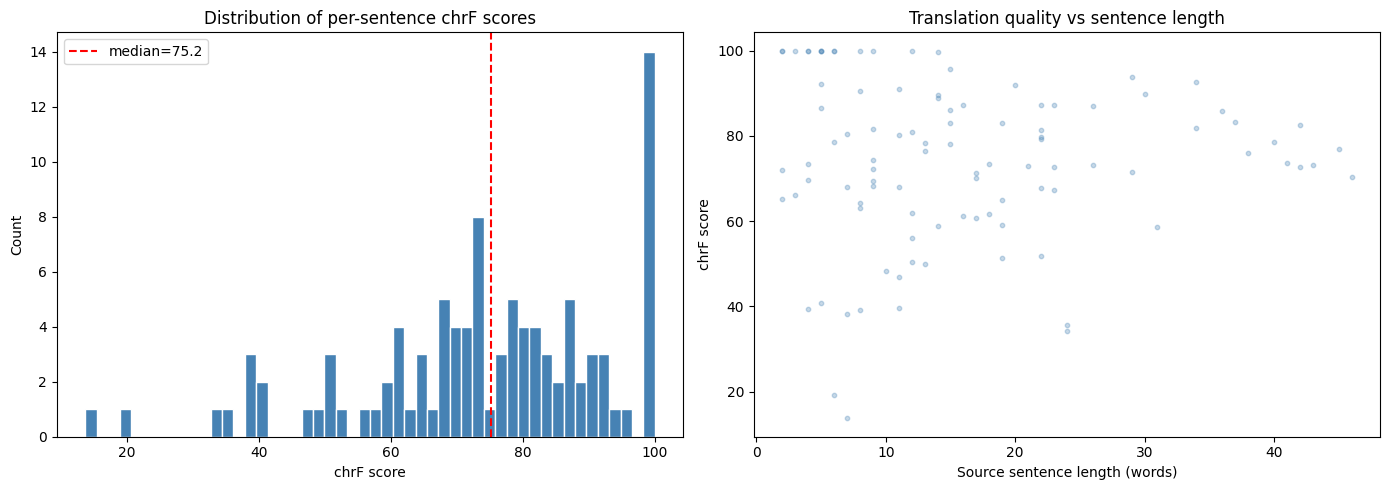

Median chrF: 75.2
Mean chrF: 74.1
Sentences below 30 chrF: 2/100


In [15]:
# Distribution of per-sentence chrF scores
chrfs = [s["chrf"] for s in sentence_scores]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(chrfs, bins=50, color="steelblue", edgecolor="white")
ax1.set_xlabel("chrF score")
ax1.set_ylabel("Count")
ax1.set_title("Distribution of per-sentence chrF scores")
ax1.axvline(np.median(chrfs), color="red", linestyle="--", label=f"median={np.median(chrfs):.1f}")
ax1.legend()

# Score vs source sentence length
src_lens = [len(s["src"].split()) for s in sentence_scores]
ax2.scatter(src_lens, chrfs, alpha=0.3, s=10, color="steelblue")
ax2.set_xlabel("Source sentence length (words)")
ax2.set_ylabel("chrF score")
ax2.set_title("Translation quality vs sentence length")

plt.tight_layout()
plt.show()

print(f"Median chrF: {np.median(chrfs):.1f}")
print(f"Mean chrF: {np.mean(chrfs):.1f}")
print(f"Sentences below 30 chrF: {sum(1 for c in chrfs if c < 30)}/{len(chrfs)}")

## Synonym analysis

Use teacher forcing to check: when the model chose a different word than the reference, was the reference word still a high-probability alternative?

In [16]:
def find_synonym_choices(src_text, ref_text, hyp_text):
    """Teacher-force the reference and find positions where the model preferred a different token."""
    src_ids = tokenizer(src_text, return_tensors="pt")["input_ids"].to(device)
    ref_ids = tokenizer(ref_text, return_tensors="pt")["input_ids"].to(device)
    src_mask = (src_ids != tokenizer.pad_token_id).to(device)
    ref_mask = (ref_ids != tokenizer.pad_token_id).to(device)

    with torch.no_grad():
        src_enc = transformer.encode(src_ids, src_mask)
        tgt_dec = transformer.decode(src_enc, ref_ids, src_mask, ref_mask)
        logits = transformer.output(tgt_dec)

    probs = F.softmax(logits[0], dim=-1)
    ref_tokens = tokenizer.convert_ids_to_tokens(ref_ids[0])

    choices = []
    for pos in range(len(ref_tokens) - 1):
        next_ref_id = ref_ids[0, pos + 1].item()
        next_ref_token = ref_tokens[pos + 1]
        ref_prob = probs[pos, next_ref_id].item()

        top_prob, top_id = probs[pos].topk(1)
        top_token = tokenizer.convert_ids_to_tokens(top_id)[0]
        top_prob = top_prob.item()

        if top_token != next_ref_token and ref_prob > 0.05:
            choices.append({
                "pos": pos,
                "ref_token": next_ref_token,
                "ref_prob": ref_prob,
                "model_token": top_token,
                "model_prob": top_prob,
                "context": " ".join(ref_tokens[max(0, pos-2):pos+1]),
            })

    return choices


synonym_choices = []
for src, ref, hyp in zip(src_sentences, ref_sentences, hyps):
    choices = find_synonym_choices(src, ref, hyp)
    for c in choices:
        c["src"] = src
        c["ref"] = ref
    synonym_choices.extend(choices)

synonym_choices.sort(key=lambda x: x["ref_prob"], reverse=True)

print(f"Found {len(synonym_choices)} positions where model preferred a different token but reference had >5% probability\n")
print("=== Top synonym choices (reference had highest probability) ===\n")
for c in synonym_choices[:20]:
    print(f"  After '{c['context']}':")
    print(f"    Model chose: '{c['model_token']}' ({c['model_prob']:.1%})")
    print(f"    Reference:   '{c['ref_token']}' ({c['ref_prob']:.1%})")
    print()

Found 187 positions where model preferred a different token but reference had >5% probability

=== Top synonym choices (reference had highest probability) ===

  After '[BOS] Gweith':
    Model chose: '##garwch' (43.3%)
    Reference:   '##gar' (43.0%)

  After 'gwasanaeth cyfieithu o':
    Model chose: 'ansawdd' (46.3%)
    Reference:   'safon' (42.4%)

  After 'mae wedi mynd':
    Model chose: 'heb' (43.9%)
    Reference:   'o' (42.0%)

  After 'task SIMS tasg':
    Model chose: 'ac' (47.2%)
    Reference:   'a' (41.9%)

  After 'yn erbyn cyflog':
    Model chose: 'isel' (46.7%)
    Reference:   '##au' (41.5%)

  After 'ac yn gwella':
    Model chose: 'drwy' (47.8%)
    Reference:   'trwy' (41.5%)

  After 'amgylchedd ##, gwerth':
    Model chose: '##iannau' (54.3%)
    Reference:   '##iant' (41.4%)

  After '##wyd y gynhadledd':
    Model chose: 'hon' (48.6%)
    Reference:   'gan' (40.3%)

  After 'ar feddyg ##aeth':
    Model chose: 'gymuned' (47.1%)
    Reference:   'yn' (40.1%)


## Mutation head analysis

Welsh has systematic consonant mutations triggered by specific preceding words. Which attention heads respond to the mutation trigger?

We translate sentences that require mutations, capture per-head cross-attention at the mutated token, and check which heads attend to the trigger word in the source.

In [18]:
# Sentences designed to trigger specific mutations
mutation_examples = [
    # Soft mutation after 'y' (the): cath -> gath, ci -> gi
    ("I saw the cat", "soft mutation: cath -> gath"),
    # Soft mutation after 'i' (to): Caerdydd -> Gaerdydd
    ("I went to Cardiff", "soft mutation: Caerdydd -> Gaerdydd"),
    # Aspirate mutation after 'a' (and): coffi -> choffi
    ("tea and coffee", "aspirate mutation after 'a'"),
    # Nasal mutation after 'yn' (in): Cymru -> Nghymru
    ("I live in Wales", "nasal mutation: Cymru -> Nghymru"),
    # Soft mutation after adjective: da -> dda
    ("very good work", "soft mutation after 'very'"),
]

mutation_results = []
for text, desc in mutation_examples:
    r = capture_all_layers(text)
    mutation_results.append((text, desc, r))
    print(f"EN: {text} ({desc})")
    print(f"CY: {r['tgt_text']}")
    print(f"    src: {r['src_tokens']}")
    print(f"    tgt: {r['tgt_tokens']}")
    print()

EN: I saw the cat (soft mutation: cath -> gath)
CY: Gwelais y gath
    src: ['[BOS]', 'I', 'saw', 'the', 'c', '##at', '[EOS]']
    tgt: ['Gwel', '##ais', 'y', 'g', '##ath', '[EOS]']



EN: I went to Cardiff (soft mutation: Caerdydd -> Gaerdydd)
CY: Es i Gaerdydd
    src: ['[BOS]', 'I', 'went', 'to', 'Cardiff', '[EOS]']
    tgt: ['Es', 'i', 'Gaerdydd', '[EOS]']



EN: tea and coffee (aspirate mutation after 'a')
CY: te a choffi
    src: ['[BOS]', 'te', '##a', 'and', 'coffee', '[EOS]']
    tgt: ['te', 'a', 'chof', '##f', '##i', '[EOS]']



EN: I live in Wales (nasal mutation: Cymru -> Nghymru)
CY: Rwy'n byw yng Nghymru
    src: ['[BOS]', 'I', 'live', 'in', 'Wales', '[EOS]']
    tgt: ["Rwy'n", 'byw', 'yng', 'Nghymru', '[EOS]']

EN: very good work (soft mutation after 'very')
CY: gwaith da iawn
    src: ['[BOS]', 'very', 'good', 'work', '[EOS]']
    tgt: ['gwaith', 'da', 'iawn', '[EOS]']



### Per-head attention at mutation points

For each mutation example, look at which heads attend to the mutation trigger word when generating the mutated token. A "mutation head" would consistently attend to the trigger across examples.

=== I saw the cat -> Gwelais y gath ===
    (soft mutation: cath -> gath)
    target tokens: ['[BOS]', 'Gwel', '##ais', 'y', 'g', '##ath', '[EOS]']



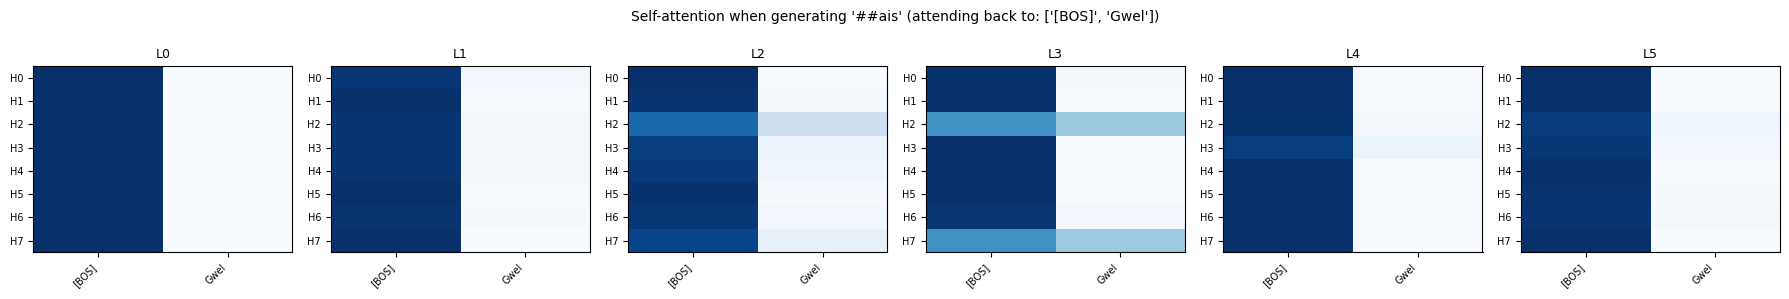

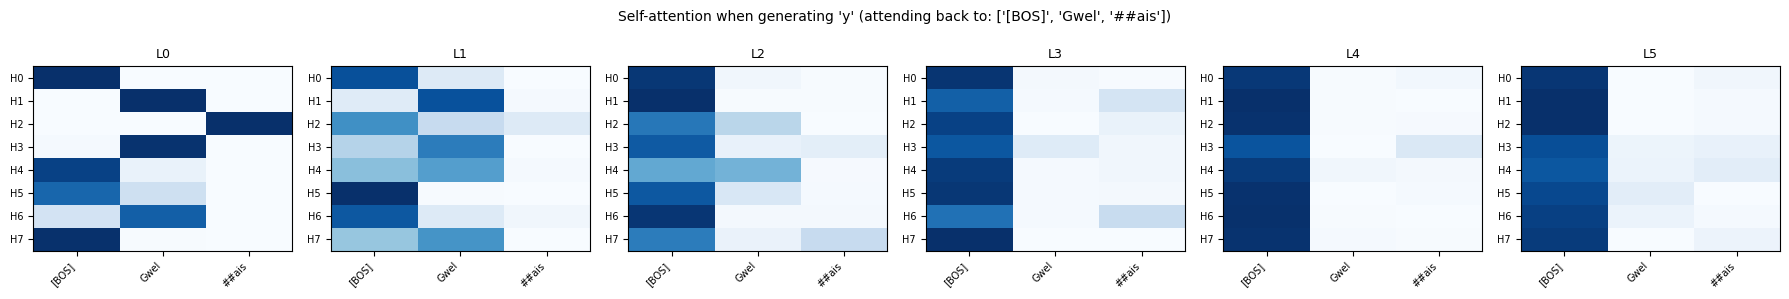

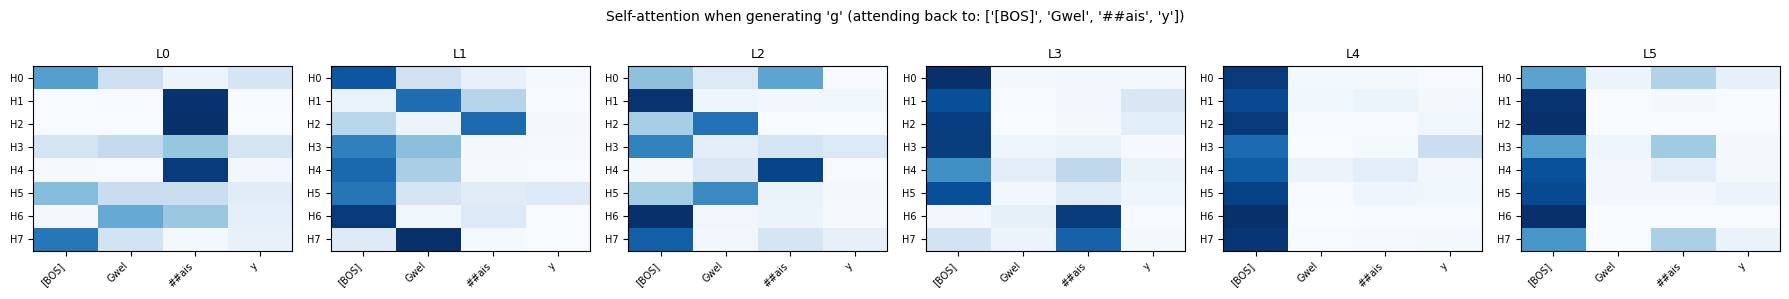

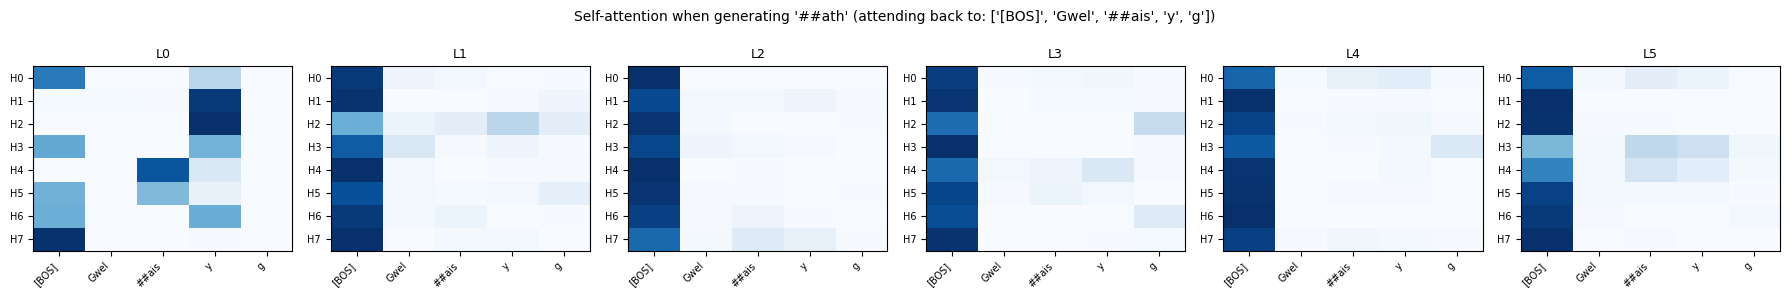

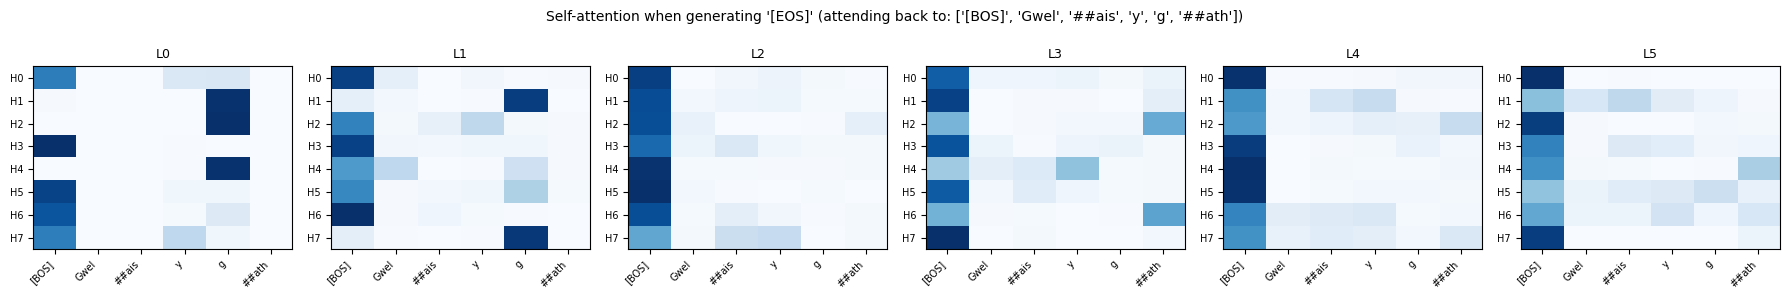


=== I went to Cardiff -> Es i Gaerdydd ===
    (soft mutation: Caerdydd -> Gaerdydd)
    target tokens: ['[BOS]', 'Es', 'i', 'Gaerdydd', '[EOS]']



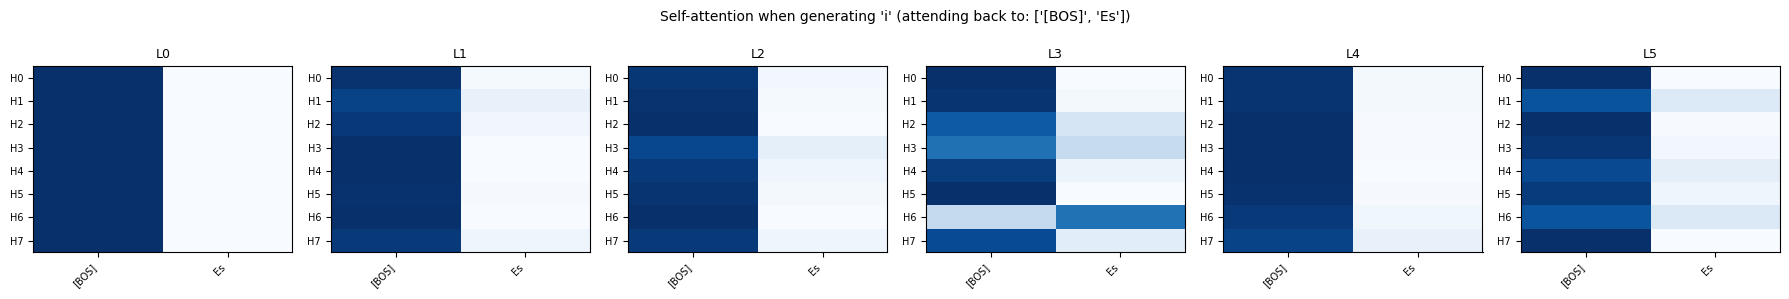

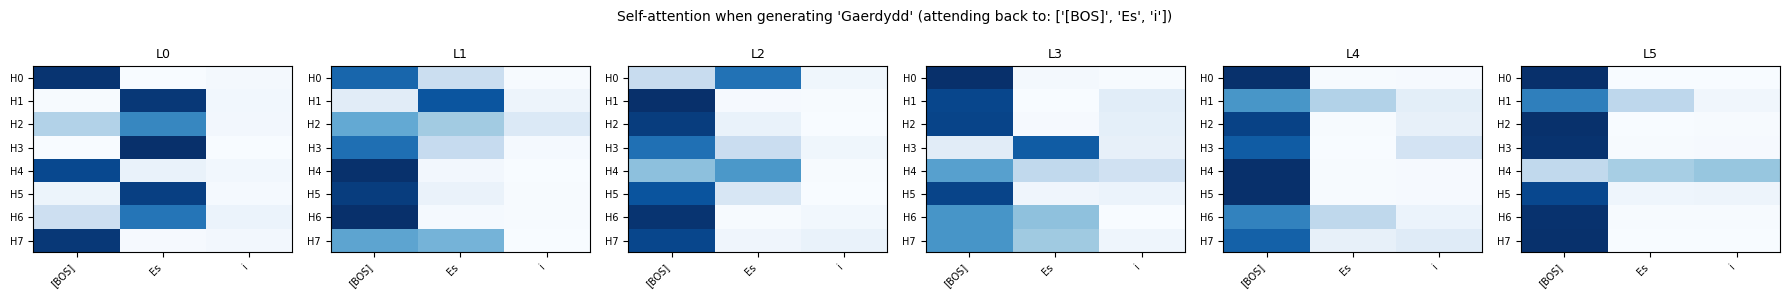

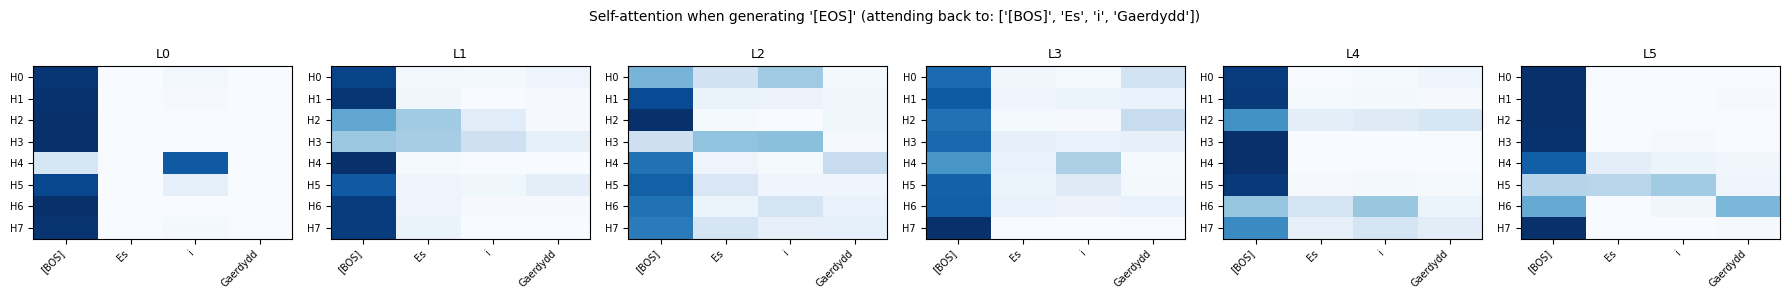


=== tea and coffee -> te a choffi ===
    (aspirate mutation after 'a')
    target tokens: ['[BOS]', 'te', 'a', 'chof', '##f', '##i', '[EOS]']



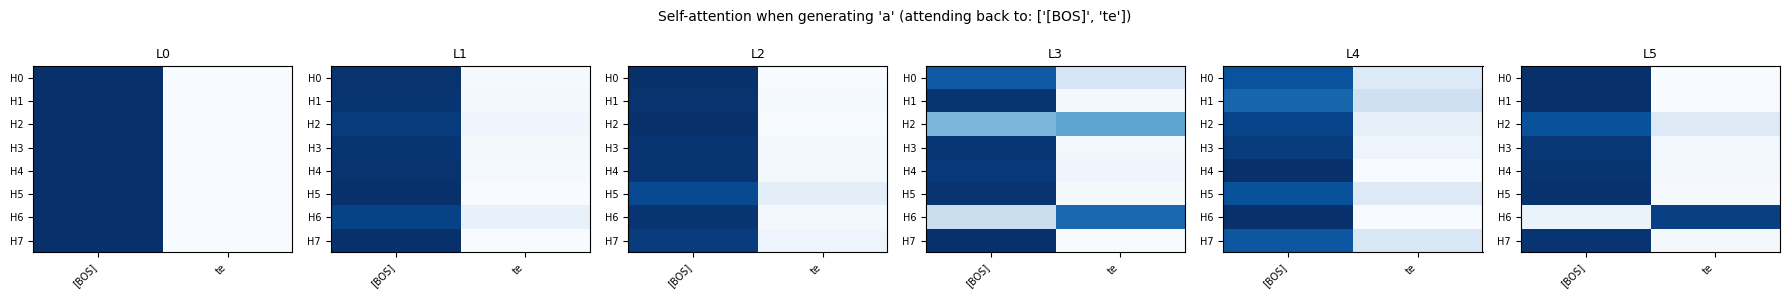

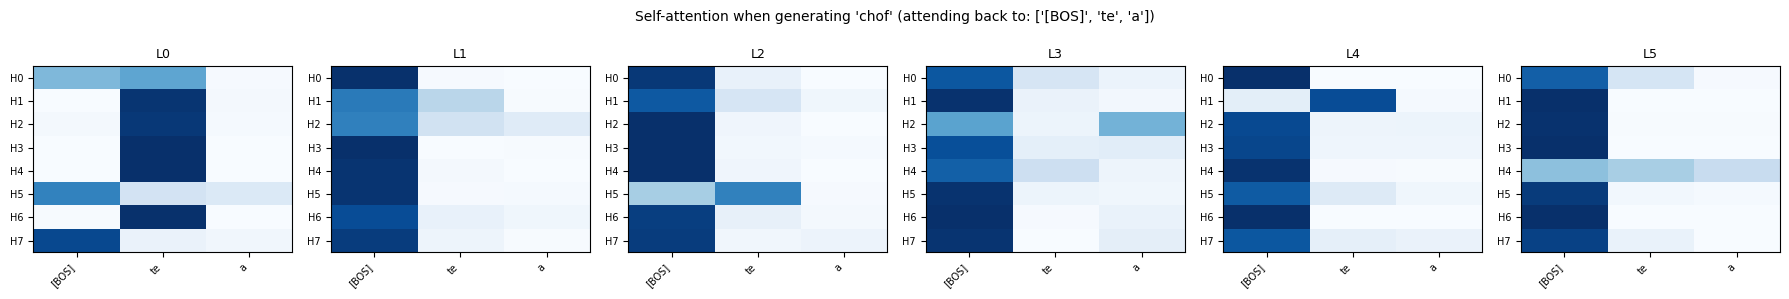

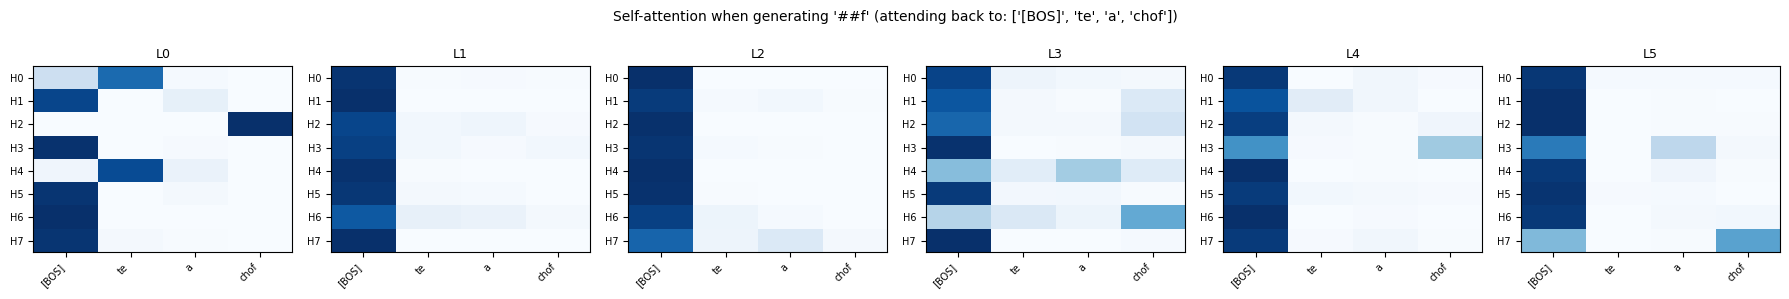

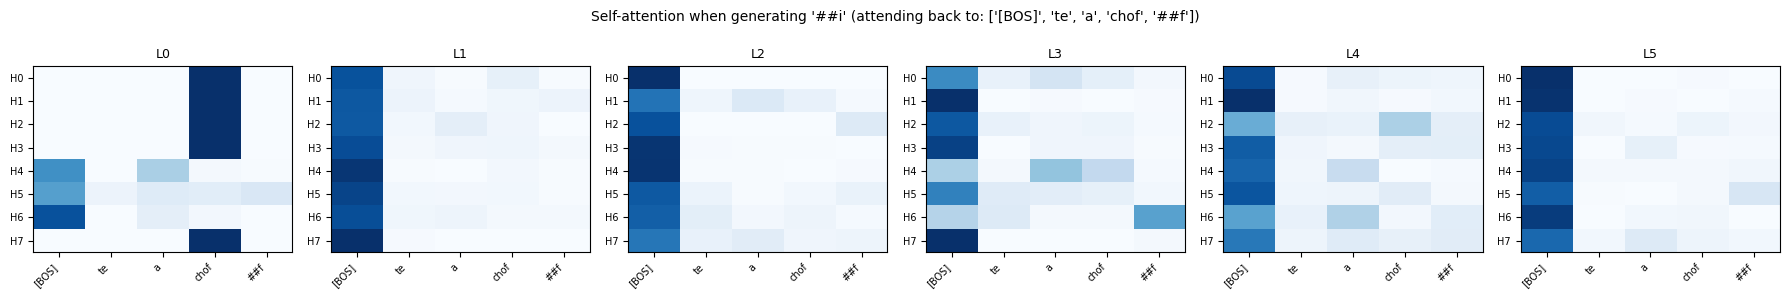

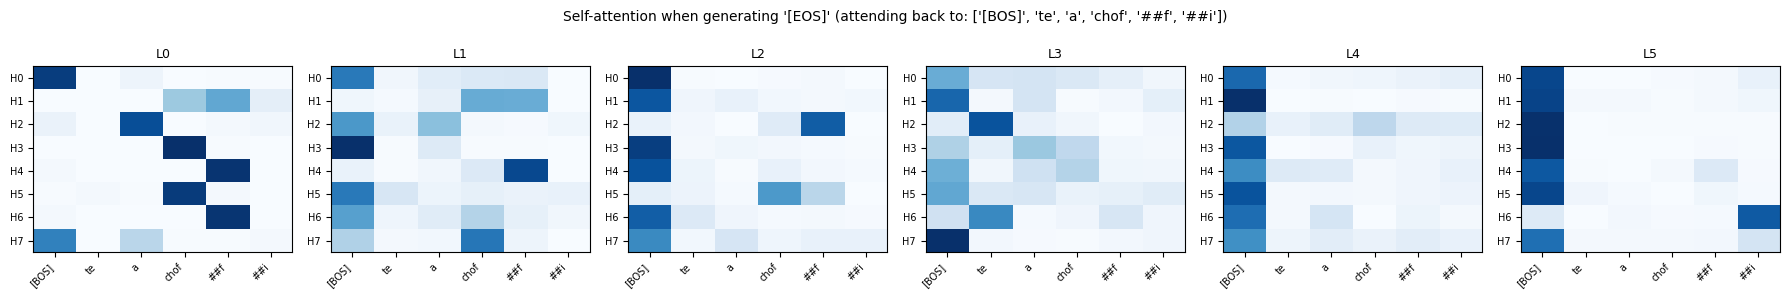


=== I live in Wales -> Rwy'n byw yng Nghymru ===
    (nasal mutation: Cymru -> Nghymru)
    target tokens: ['[BOS]', "Rwy'n", 'byw', 'yng', 'Nghymru', '[EOS]']



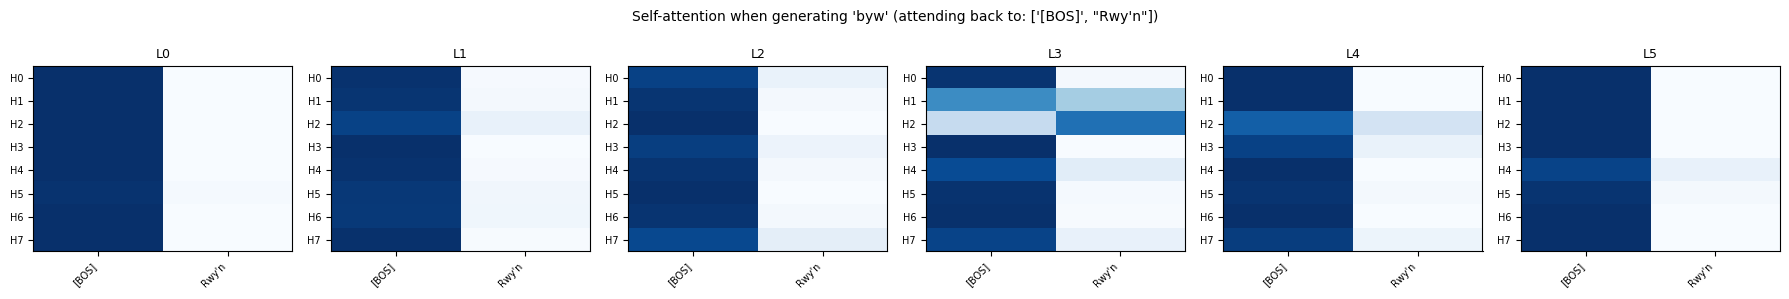

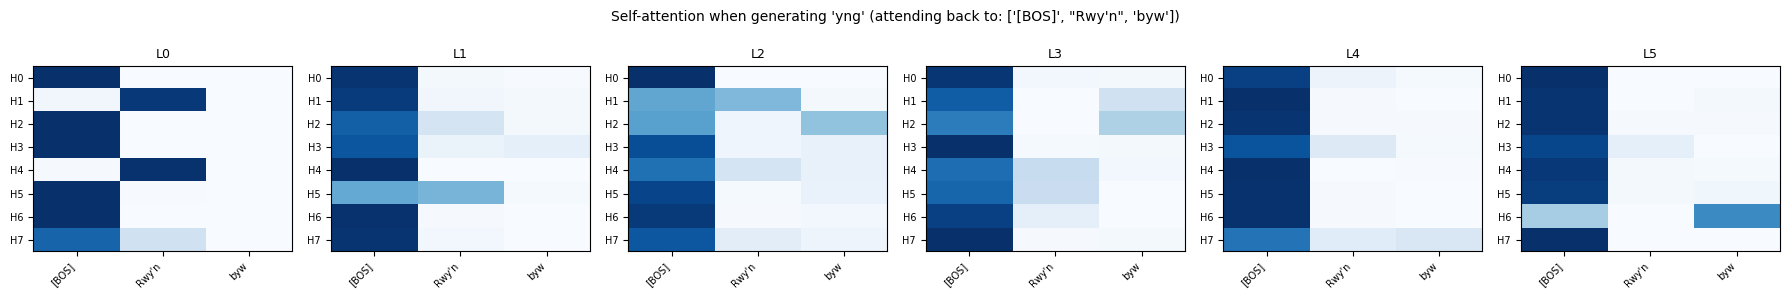

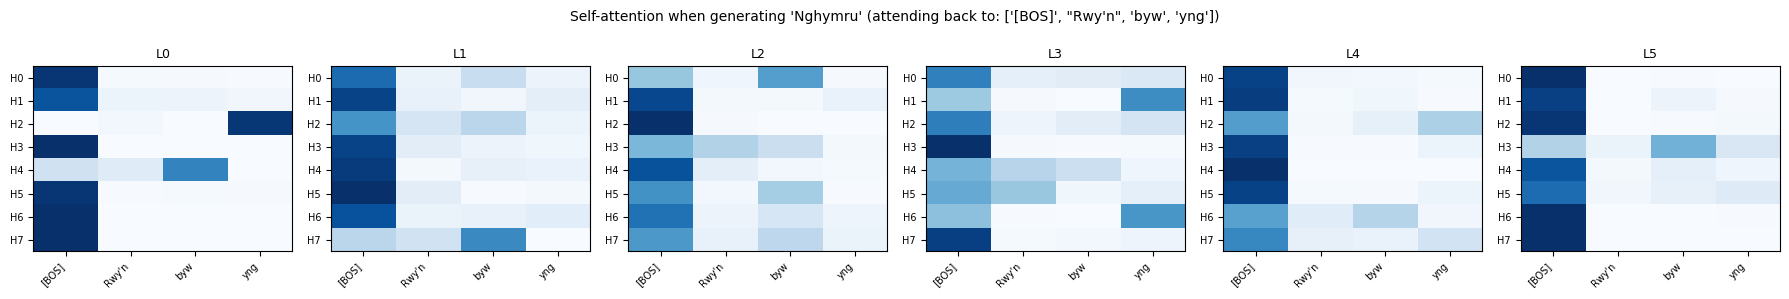

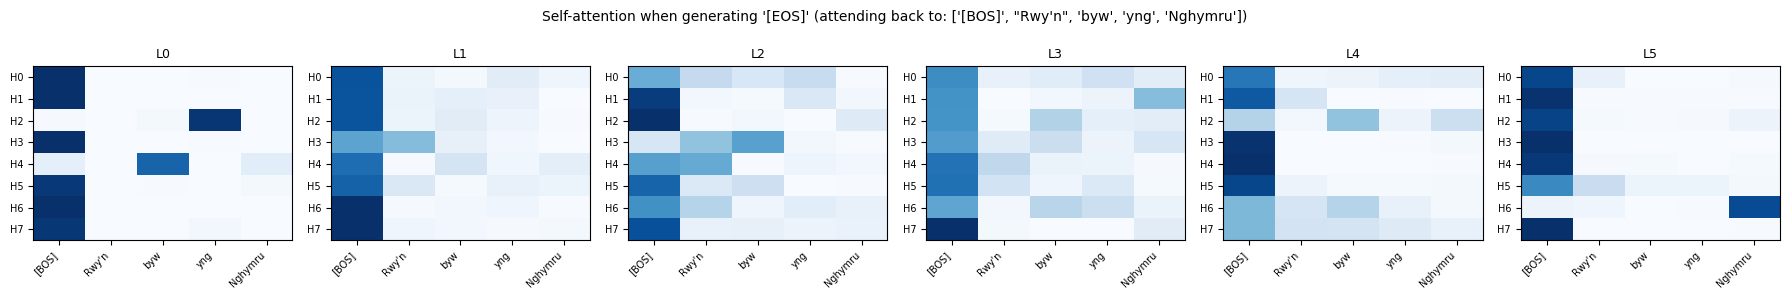


=== very good work -> gwaith da iawn ===
    (soft mutation after 'very')
    target tokens: ['[BOS]', 'gwaith', 'da', 'iawn', '[EOS]']



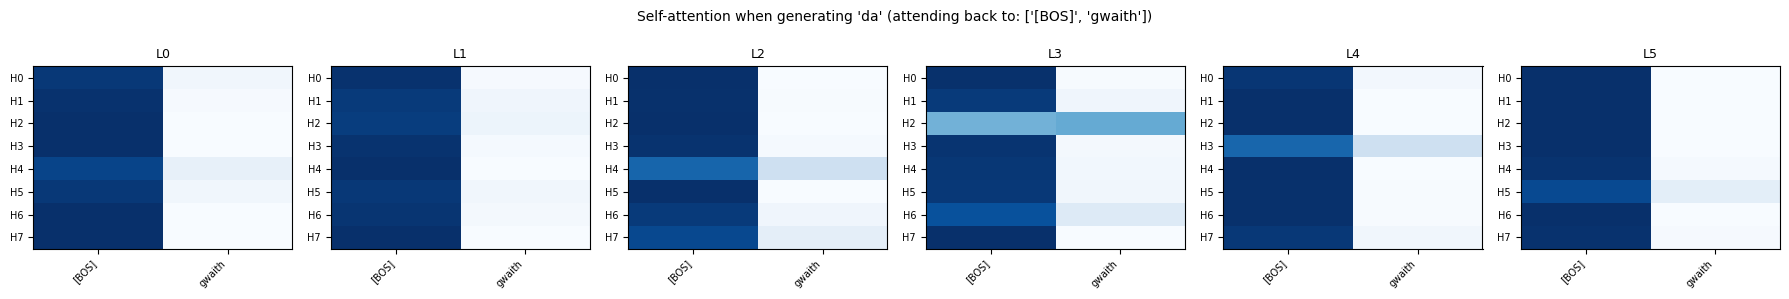

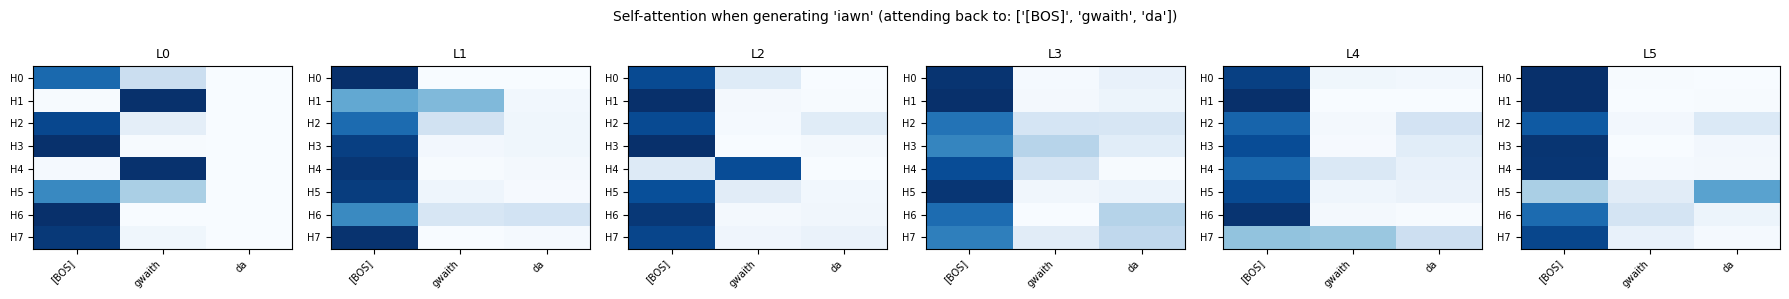

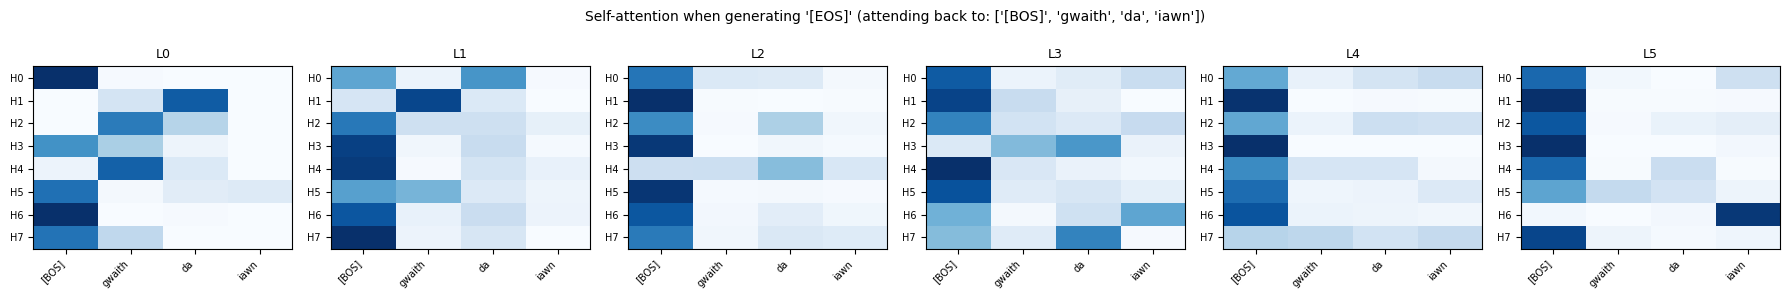

In [19]:
# For each mutation example, show decoder self-attention at the mutated token
# This reveals which heads attend back to the trigger word (y, a, yng, etc.)

num_layers = len(transformer.decoder.layers)
num_heads = transformer.decoder.layers[0].self_attention.num_heads

for text, desc, r in mutation_results:
    tgt_tokens = ["[BOS]"] + r["tgt_tokens"]
    print(f"=== {text} -> {r['tgt_text']} ===")
    print(f"    ({desc})")
    print(f"    target tokens: {tgt_tokens}\n")

    # Find mutation-related steps (where the mutated word is generated)
    # Show self-attention for each step as a per-head heatmap
    for step in range(len(r["tgt_tokens"])):
        generated_token = r["tgt_tokens"][step]
        context_tokens = tgt_tokens[:step+1]  # tokens generated so far (including BOS)

        if len(context_tokens) < 2:
            continue

        fig, axes = plt.subplots(1, num_layers, figsize=(3 * num_layers, 3))
        fig.suptitle(f"Self-attention when generating '{generated_token}' (attending back to: {context_tokens})", fontsize=10)

        for layer in range(num_layers):
            ax = axes[layer]
            attn = r["self_attns"][step][layer]  # (num_heads, tgt_len_so_far)
            ax.imshow(attn, aspect="auto", cmap="Blues")
            ax.set_title(f"L{layer}", fontsize=9)
            ax.set_yticks(range(num_heads))
            ax.set_yticklabels([f"H{h}" for h in range(num_heads)], fontsize=7)
            ax.set_xticks(range(len(context_tokens)))
            ax.set_xticklabels(context_tokens, rotation=45, ha="right", fontsize=7)

        plt.tight_layout()
        plt.show()
    print()

### Head specialisation summary

Aggregate across all mutation examples: which (layer, head) pairs consistently attend to specific source positions? A head that always attends to the word being translated is an "alignment head". A head that attends to the preceding context (mutation trigger) is a "grammar head".

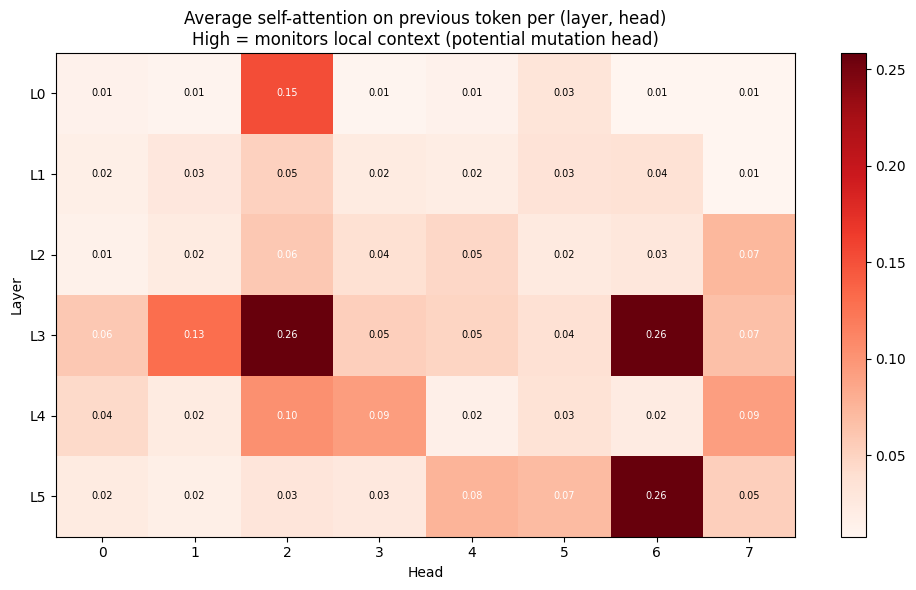

Heads most focused on previous token (potential mutation/grammar heads):
  Layer 3, Head 6: avg attention on prev token = 0.258
  Layer 3, Head 2: avg attention on prev token = 0.258
  Layer 5, Head 6: avg attention on prev token = 0.258
  Layer 0, Head 2: avg attention on prev token = 0.152
  Layer 3, Head 1: avg attention on prev token = 0.130

Heads least focused on previous token:
  Layer 0, Head 1: avg attention on prev token = 0.010
  Layer 0, Head 3: avg attention on prev token = 0.009
  Layer 0, Head 6: avg attention on prev token = 0.008
  Layer 1, Head 7: avg attention on prev token = 0.008
  Layer 0, Head 7: avg attention on prev token = 0.008


In [20]:
# For each (layer, head), compute how much it attends to the immediately preceding token
# A high "previous token attention" score suggests the head is monitoring local context (mutation triggers)

prev_token_attn = np.zeros((num_layers, num_heads))
prev_token_count = 0

for text, desc, r in mutation_results:
    for step in range(len(r["tgt_tokens"])):
        if step == 0:
            continue
        for layer in range(num_layers):
            attn = r["self_attns"][step][layer]  # (num_heads, tgt_len_so_far)
            for head in range(num_heads):
                # Attention weight on the immediately preceding token
                prev_token_attn[layer, head] += attn[head, -1]  # last position = previous token
        prev_token_count += 1

prev_token_attn /= prev_token_count

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(prev_token_attn, aspect="auto", cmap="Reds")
ax.set_xlabel("Head")
ax.set_ylabel("Layer")
ax.set_xticks(range(num_heads))
ax.set_yticks(range(num_layers))
ax.set_yticklabels([f"L{i}" for i in range(num_layers)])
ax.set_title("Average self-attention on previous token per (layer, head)\nHigh = monitors local context (potential mutation head)")
plt.colorbar(im, ax=ax)

for i in range(num_layers):
    for j in range(num_heads):
        ax.text(j, i, f"{prev_token_attn[i,j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if prev_token_attn[i,j] > prev_token_attn.mean() else "black")

plt.tight_layout()
plt.show()

flat = [(prev_token_attn[l, h], l, h) for l in range(num_layers) for h in range(num_heads)]
flat.sort(reverse=True)
print("Heads most focused on previous token (potential mutation/grammar heads):")
for score, l, h in flat[:5]:
    print(f"  Layer {l}, Head {h}: avg attention on prev token = {score:.3f}")
print("\nHeads least focused on previous token:")
for score, l, h in flat[-5:]:
    print(f"  Layer {l}, Head {h}: avg attention on prev token = {score:.3f}")

### Mutation vs non-mutation contrast

Compare previous-token attention at positions where a mutation occurs versus positions where it doesn't. A "mutation head" should attend more to the previous token specifically when that token is a mutation trigger.

Mutation positions: 13, Non-mutation positions: 53



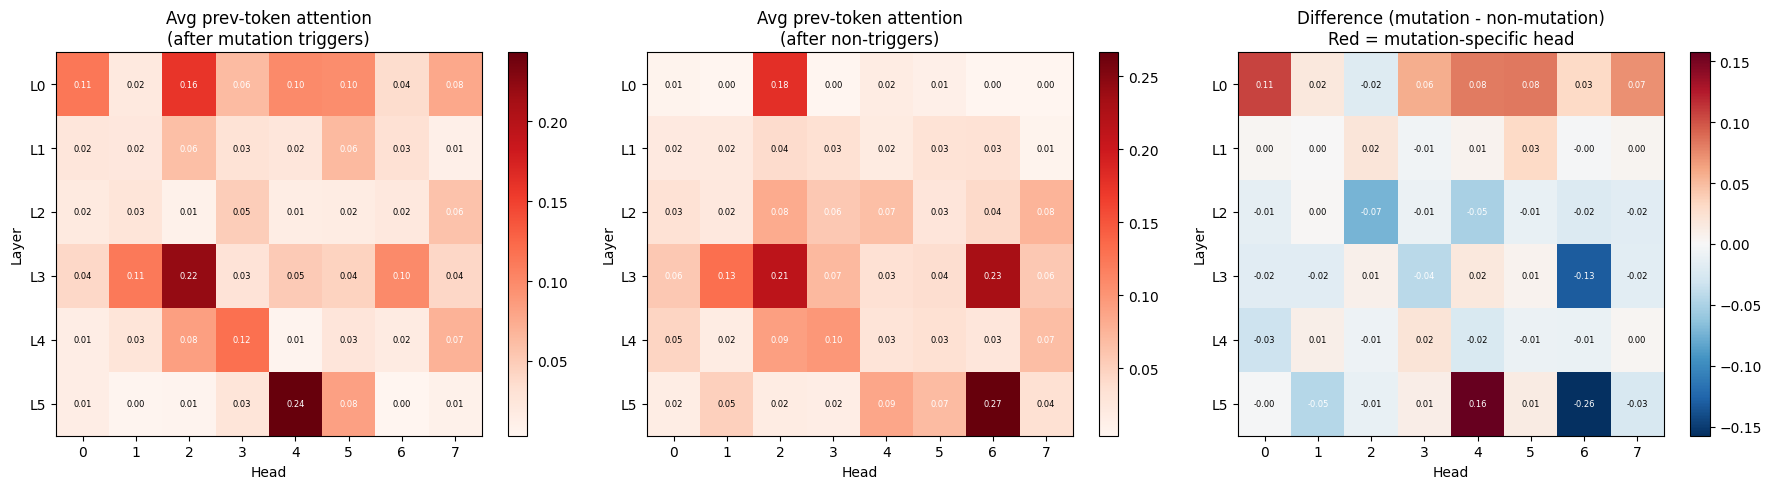

Heads with most mutation-specific previous-token attention:
  Layer 5, Head 4: diff=+0.157 (mutation=0.243, non-mutation=0.086)
  Layer 0, Head 0: diff=+0.107 (mutation=0.114, non-mutation=0.007)
  Layer 0, Head 5: diff=+0.084 (mutation=0.096, non-mutation=0.013)
  Layer 0, Head 4: diff=+0.082 (mutation=0.099, non-mutation=0.018)
  Layer 0, Head 7: diff=+0.072 (mutation=0.077, non-mutation=0.004)

Heads with most non-mutation-specific previous-token attention:
  Layer 5, Head 1: diff=-0.045 (mutation=0.005, non-mutation=0.050)
  Layer 2, Head 4: diff=-0.052 (mutation=0.015, non-mutation=0.066)
  Layer 2, Head 2: diff=-0.073 (mutation=0.010, non-mutation=0.082)
  Layer 3, Head 6: diff=-0.131 (mutation=0.099, non-mutation=0.231)
  Layer 5, Head 6: diff=-0.263 (mutation=0.003, non-mutation=0.266)


In [21]:
# Pairs: (sentence, step index of mutated token, trigger token)
# We need to identify which steps have mutations vs which don't

mutation_triggers = {"y", "i", "a", "yn", "yng", "o", "ei", "ei", "fy", "dy"}

# Run a larger set of sentences through the model
contrast_sentences = [
    "I saw the cat",
    "I went to Cardiff",
    "tea and coffee",
    "I live in Wales",
    "The school is good",
    "She has a new car",
    "We need more money",
    "The council will decide",
    "I want to buy a house",
    "Children and teachers",
    "He went to the shop",
    "The government announced a new policy",
    "I read the book",
    "Food and drink for everyone",
    "She works in Swansea",
]

contrast_results = []
for text in contrast_sentences:
    r = capture_all_layers(text)
    contrast_results.append(r)

# Collect previous-token attention, split by mutation vs non-mutation
mutation_attn = np.zeros((num_layers, num_heads))
mutation_count = 0
non_mutation_attn = np.zeros((num_layers, num_heads))
non_mutation_count = 0

for r in contrast_results:
    tgt_tokens = ["[BOS]"] + r["tgt_tokens"]
    for step in range(1, len(r["tgt_tokens"])):
        prev_token = tgt_tokens[step].lower().rstrip(".,;:!?")
        is_mutation = prev_token in mutation_triggers

        for layer in range(num_layers):
            attn = r["self_attns"][step][layer]
            for head in range(num_heads):
                prev_attn = attn[head, -1]
                if is_mutation:
                    mutation_attn[layer, head] += prev_attn
                else:
                    non_mutation_attn[layer, head] += prev_attn

        if is_mutation:
            mutation_count += 1
        else:
            non_mutation_count += 1

mutation_attn /= max(mutation_count, 1)
non_mutation_attn /= max(non_mutation_count, 1)
diff = mutation_attn - non_mutation_attn

print(f"Mutation positions: {mutation_count}, Non-mutation positions: {non_mutation_count}\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(mutation_attn, aspect="auto", cmap="Reds")
axes[0].set_title("Avg prev-token attention\n(after mutation triggers)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(non_mutation_attn, aspect="auto", cmap="Reds")
axes[1].set_title("Avg prev-token attention\n(after non-triggers)")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(diff, aspect="auto", cmap="RdBu_r", vmin=-diff.max(), vmax=diff.max())
axes[2].set_title("Difference (mutation - non-mutation)\nRed = mutation-specific head")
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
    ax.set_xticks(range(num_heads))
    ax.set_yticks(range(num_layers))
    ax.set_yticklabels([f"L{i}" for i in range(num_layers)])

for ax, data in zip(axes, [mutation_attn, non_mutation_attn, diff]):
    for i in range(num_layers):
        for j in range(num_heads):
            ax.text(j, i, f"{data[i,j]:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if abs(data[i,j]) > abs(data).mean() else "black")

plt.tight_layout()
plt.show()

# Report heads with biggest positive difference
flat = [(diff[l, h], l, h) for l in range(num_layers) for h in range(num_heads)]
flat.sort(reverse=True)
print("Heads with most mutation-specific previous-token attention:")
for d, l, h in flat[:5]:
    print(f"  Layer {l}, Head {h}: diff={d:+.3f} (mutation={mutation_attn[l,h]:.3f}, non-mutation={non_mutation_attn[l,h]:.3f})")
print("\nHeads with most non-mutation-specific previous-token attention:")
for d, l, h in flat[-5:]:
    print(f"  Layer {l}, Head {h}: diff={d:+.3f} (mutation={mutation_attn[l,h]:.3f}, non-mutation={non_mutation_attn[l,h]:.3f})")

## Investigate a bad translation

Pick a poor translation from above and run it through `translate_with_internals` to see where the model goes wrong.

In [ ]:
worst = sentence_scores[0]
print(f"Worst sentence (chrF={worst['chrf']:.1f}):")
print(f"  EN:  {worst['src']}")
print(f"  REF: {worst['ref']}")
print(f"  HYP: {worst['hyp']}")

bad_result = capture_all_layers(worst["src"])

print(f"\n--- Token-level analysis ---")
for i, (token, prob_info) in enumerate(zip(bad_result["tgt_tokens"], bad_result["probs"])):
    top3 = ", ".join(f"{t}({p:.2f})" for t, p in zip(prob_info["top_tokens"][:3], prob_info["top_probs"][:3]))
    print(f"  Step {i:>2}: chose '{token}' | top3: {top3} | entropy: {prob_info['entropy']:.2f}")

In [ ]:
# Cross-attention for the worst translation (averaged over all layers)
bad_cross = np.stack([
    np.stack([bad_result["cross_attns"][step][layer] for layer in range(num_layers)]).mean(axis=(0, 1))
    for step in range(len(bad_result["tgt_tokens"]))
])

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(bad_cross, aspect="auto", cmap="Blues")
ax.set_xticks(range(len(bad_result["src_tokens"])))
ax.set_xticklabels(bad_result["src_tokens"], rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(bad_result["tgt_tokens"])))
ax.set_yticklabels(bad_result["tgt_tokens"], fontsize=9)
ax.set_xlabel("Source tokens")
ax.set_ylabel("Target tokens")
ax.set_title(f"Cross-attention for worst translation (chrF={worst['chrf']:.1f})")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()